# Data Preprocessing — Enhanced Teaching Notebook

**Objective:** A deep, classroom-ready notebook that teaches dataset understanding, feature selection, normalization, and cleaning using the Titanic dataset. Each section includes *theory*, *intuition*, **step-by-step code with comments**, and **visual learning aids**.


## Notebook layout

1. Import libraries
2. Load dataset & initial inspection
3. Deep EDA (distributions, missingness, outliers, correlation)
4. Data cleaning strategies (imputation, outliers, encoding)
5. Feature selection (filter, wrapper, embedded, multicollinearity, PCA)
6. Feature scaling & transformations (visual comparisons)
7. Preprocessing pipelines and Training/Testing/Validation
8. Exercises and teaching notes


In [ ]:
# 1) Imports - core libraries used in data science and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, VarianceThreshold
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


## 2) Load dataset & initial inspection

**Teaching note:** Always inspect rows, data types, missing values, and basic distributions before making cleaning decisions.

The Titanic dataset is a historical record detailing passengers aboard the RMS Titanic, primarily used for predictive modeling and data analysis in machine learning. Each row represents one passenger and includes key information such as:

- **PassengerId**: Unique identifier for each passenger
- **Survived**: Indicates if the passenger survived (1) or not (0)
- **Pclass**: Passenger’s ticket class (1st, 2nd, or 3rd)
- **Name**: Full name of the passenger
- **Sex**: Gender of the passenger
- **Age**: Age in years
- **SibSp**: Number of siblings or spouses aboard
- **Parch**: Number of parents or children aboard
- **Ticket**: Ticket number
- **Fare**: Amount paid for the ticket
- **Cabin**: Cabin number (often missing)
- **Embarked**: Port where the passenger boarded (C = Cherbourg, Q = Queenstown, S = Southampton)

The dataset is widely used by beginners to learn about classification tasks—especially predicting whether a passenger survived based on available features. It contains both categorical (e.g., sex, class) and numerical (e.g., age, fare) variables, making it a perfect sample for demonstrating data cleaning, feature engineering, and various machine learning model techniques.


In [ ]:
# Load Titanic dataset (public GitHub link)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Show basic info and first rows
print('Shape:', df.shape)
display(df.head())
print('\nData types:')
display(df.dtypes)

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Data types:


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


### Why these checks?
- `shape` tells how many rows/columns — helps estimate data size.
- `head()` gives a feel for the columns (names, values, text fields).
- `dtypes` helps decide which preprocessing (scaling, encoding) each column needs.


In [ ]:
# Quick summary statistics for numeric and categorical features
print('\nNumeric summary:')
display(df.describe())

print('\nCategorical summary:')
display(df.describe(include=['object', 'category']))

# Missing value counts
print('\nMissing values per column:')
display(df.isnull().sum())


Numeric summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Categorical summary:


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644



Missing values per column:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## 3) Deep EDA

**Goals:**
- Visualize distributions to detect skew and outliers.
- Visualize missingness pattern.
- Compute correlations to detect redundant features.


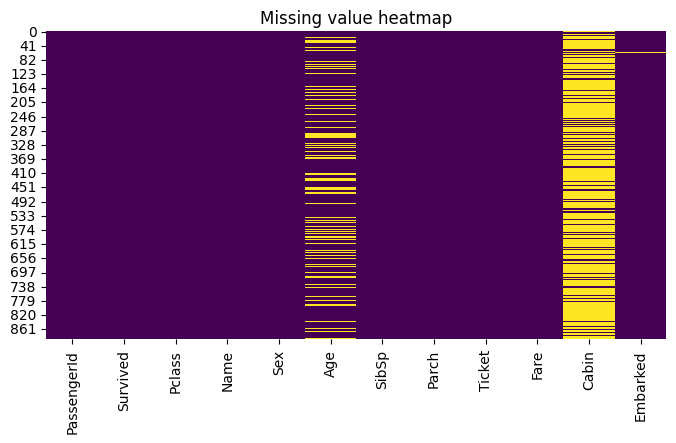

In [ ]:
# Missingness heatmap
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing value heatmap')
plt.show()

This plot is a "missing value heatmap" for the Titanic dataset, showing where data is missing in each feature (column) for all passengers (rows).

- **Rows** correspond to individual passengers.
- **Columns** represent each feature: PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, and Embarked.
- **Yellow lines** indicate missing data, and **purple/black** indicates data is present.

From the plot:

- **Age** has several missing values (many yellow lines).
- **Cabin** has the most missing values, with yellow lines almost throughout the whole column.
- **Fare** and **Embarked** have very few missing values (just a couple of yellow lines).
- All other features (PassengerId, Survived, Pclass, Name, Sex, SibSp, Parch, Ticket) have no missing data—the columns are completely dark.

This type of plot helps quickly identify which columns have missing data so you can decide how to handle them (e.g., fill with averages, remove the column, etc.) during data cleaning.

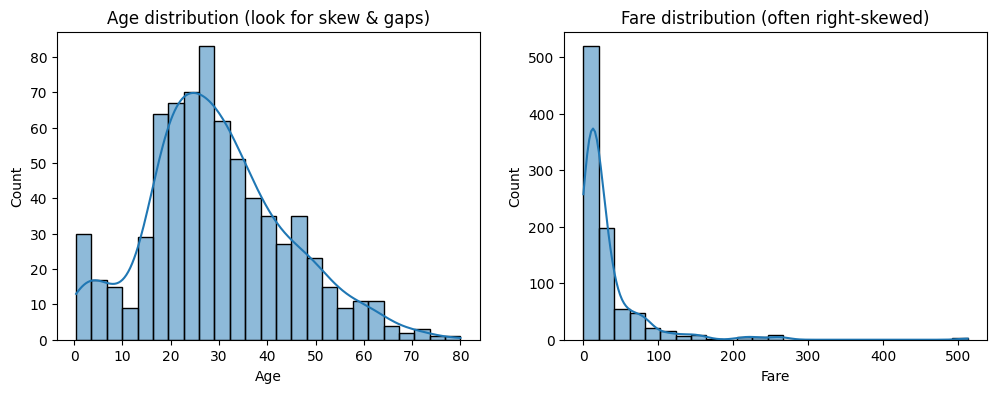

In [ ]:
# Distribution plots for Age and Fare with comments
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['Age'].dropna(), kde=True, bins=25)
plt.title('Age distribution (look for skew & gaps)')

plt.subplot(1,2,2)
sns.histplot(df['Fare'].dropna(), kde=True, bins=25)
plt.title('Fare distribution (often right-skewed)')
plt.show()

This image shows the distribution of the "Age" and "Fare" columns from the Titanic dataset, using histograms with smooth curves to visualize the data.

### Left Plot: Age Distribution

- The "Age" histogram displays how ages are spread among passengers.
- Most ages are grouped between 20 and 40 years, forming a bell-shaped curve, but with some skew to the right (toward older ages).
- There are gaps, especially at higher ages, suggesting some ages are less common or missing from the data.
- The shape roughly resembles a normal distribution, but it's not perfectly symmetric.


### Right Plot: Fare Distribution

- The "Fare" histogram shows most passengers paid lower fares.
- There is a sharp peak at the very low end, with the count dropping rapidly as fare increases.
- The long "tail" to the right means a few passengers paid much higher fares—this is called right-skewed or positively skewed.
- This skewness is typical in real-world prices, where most pay less and only a few pay a lot.

These visualizations help reveal which values are most common, highlight skewness, and show if special handling is needed (such as log transformation for skewed fares) during data preprocessing.

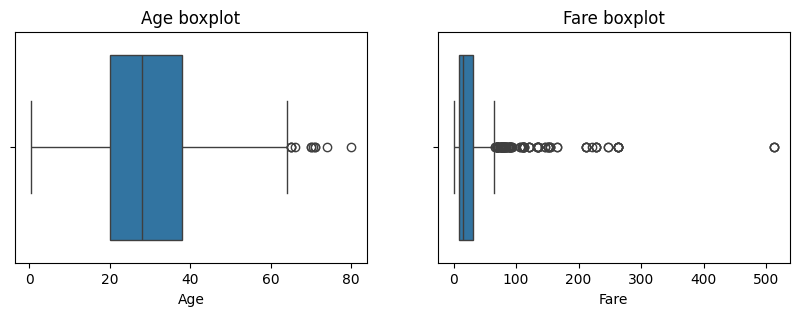

In [ ]:
# Boxplots to highlight outliers
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.boxplot(x=df['Age'])
plt.title('Age boxplot')

plt.subplot(1,2,2)
sns.boxplot(x=df['Fare'].fillna(0))
plt.title('Fare boxplot')
plt.show()

This image shows boxplots for the "Age" and "Fare" columns from the Titanic dataset, helping visualize the spread and spot outliers in each feature.

### Age Boxplot (left)

- The central box captures the middle 50% of ages (from the first to the third quartile).
- The line inside the box is the median age (the value in the middle if all ages are sorted).
- "Whiskers" extend to the typical minimum and maximum values, but not including extreme outliers.
- Any points outside the whiskers are shown as separate dots—these are considered outliers (unusually low or high ages for this group).
- In this plot, ages mostly range from childhood to mid-adulthood, with a few older outliers beyond age 60.


### Fare Boxplot (right)

- Similar structure: median line, box for middle 50% of fares, whiskers for typical range, outliers as dots.
- The box is very squished toward the lower end, showing that most fares are low.
- There are many outliers—passengers who paid much higher fares—spread across the top, even as high as 500.
- This supports that fare data is strongly right-skewed with many extreme high values.

Boxplots are useful for quickly comparing the "typical" data and spotting outliers that might need special attention in analysis or modeling.

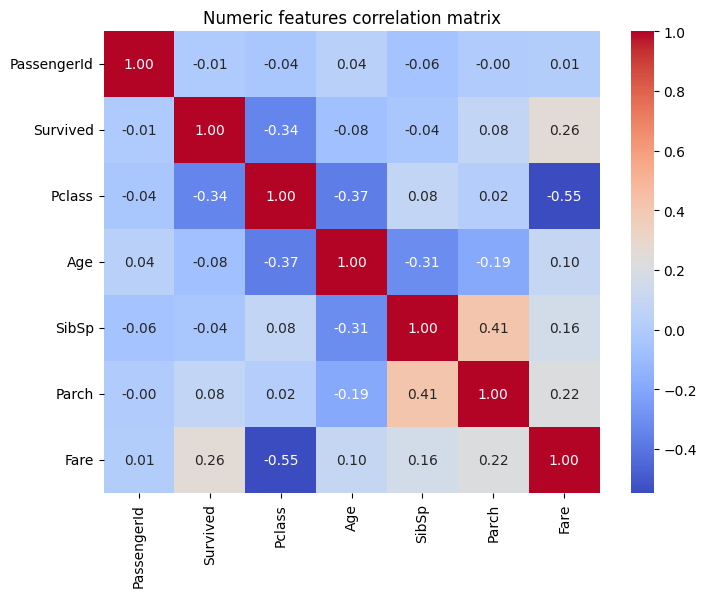

In [ ]:
# Correlation matrix for numeric features
plt.figure(figsize=(8,6))
num = df.select_dtypes(include=[np.number])
corr = num.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric features correlation matrix')
plt.show()

This is a correlation matrix heatmap for the numeric features in the Titanic dataset. It visually shows how pairs of columns (features) are related to each other, with values from -1 (strong negative correlation) to +1 (strong positive correlation).

- **Diagonal values are always 1.0:** Each feature is perfectly correlated with itself.
- **Shades of blue:** Indicate a negative correlation. For example, Fare and Pclass (-0.55) are strongly negatively correlated, meaning higher class (lower Pclass number) tends to be associated with higher fares.
- **Shades of red:** Indicate a positive correlation. SibSp and Parch (0.41) are moderately positively correlated, suggesting passengers with siblings/spouses onboard often have accompanying parents/children.
- **Near-zero values:** Show very little correlation. Many feature pairs have weak or nonexistent relationships, like Age and Survived (-0.08).
- **Survived and Fare (0.26):** There is a slight positive correlation, meaning those who paid higher fares were more likely to survive, possibly reflecting social or economic differences in rescue priority.

This matrix helps analysts quickly spot which features may be strongly related (and thus might be redundant or provide useful prediction signals) and which are largely independent in their effect. It's an important step in exploratory data analysis.


### Teaching note: Correlation
- Correlation near ±1 indicates strong linear relationship.
- Strongly correlated features may be redundant — consider removing one of a correlated pair.


## 4) Data Cleaning Strategies

**Teaching note:** Demonstrating multiple strategies with reasoning: drop, simple impute, KNN impute, cap outliers, and encode categoricals.


This code provides an overview of three common strategies to handle missing values in the Titanic dataset:

1. **Median Imputation for Age**: Missing ages are filled in with the median age. The median is less affected by extreme values, making it a robust choice for numerical data.
2. **Mode Imputation for Embarked**: For the categorical "Embarked" column, missing values are replaced by the mode, which is the most frequent category. This is a simple way to fill gaps in categorical data.
3. **K-Nearest Neighbors (KNN) Imputation**: This is a more advanced method. It predicts missing values by looking at similar rows based on other numeric features (Age, Fare, SibSp, Parch), finding the nearest neighbors, and imputing missing data using their values. This often yields better estimates than simple mean or mode filling.

In summary, the code demonstrates how to fill missing values using simple statistical methods and a more complex, similarity-based method, ensuring the dataset is complete and ready for machine learning models.

In [ ]:
# Make a working copy for cleaning examples
data = df.copy()

# Strategy 1: Simple imputation for Age (median) - robust to outliers
data['Age_median'] = data['Age'].fillna(data['Age'].median())

# Strategy 2: Fill Embarked with mode (most common)
data['Embarked_mode'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Strategy 3: KNN imputation example (requires numeric columns)
knn_imp = KNNImputer(n_neighbors=5)
knn_cols = ['Age','Fare','SibSp','Parch']
knn_sample = data[knn_cols]
knn_imputed = pd.DataFrame(knn_imp.fit_transform(knn_sample), columns=knn_cols)
print('KNN imputation example (first rows):')
display(knn_imputed.head())

KNN imputation example (first rows):


,Age,Fare,SibSp,Parch
0,22.0,7.2500,1.0,0.0
1,38.0,71.2833,1.0,0.0
2,26.0,7.9250,0.0,0.0
3,35.0,53.1000,1.0,0.0
4,35.0,8.0500,0.0,0.0


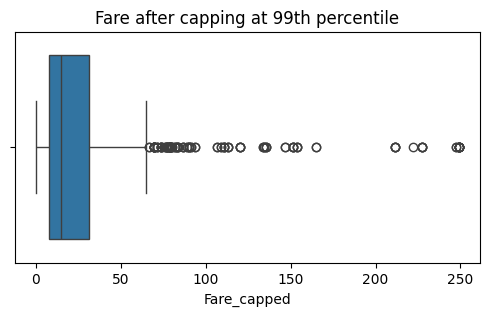

In [ ]:
# Outlier handling: capping (winsorizing) Fare at 99th percentile
cap = data['Fare'].quantile(0.99)
data['Fare_capped'] = np.where(data['Fare']>cap, cap, data['Fare'])

plt.figure(figsize=(6,3))
sns.boxplot(x=data['Fare_capped'].fillna(0))
plt.title('Fare after capping at 99th percentile')
plt.show()

This boxplot shows the distribution of the "Fare" column from the Titanic dataset after applying a technique called "capping" at the 99th percentile.

- **Capping** means limiting all fares above a certain value (the 99th percentile) to that maximum value.
- Most of the passenger fares are low, so the box is grouped close to zero.
- Outliers above the 99th percentile (extremely high fares) have been brought down to the capped maximum, reducing their effect on the plot but still showing them as separate dots.
- This process helps to minimize the influence of extreme values or outliers during model training, so they don't distort the results.

In short, capping at the 99th percentile makes the "Fare" feature more manageable for analysis by cutting off the most extreme fares and preventing them from overwhelming the rest of the data.

In [ ]:
# Encoding categorical variables - options and demo
# 1) Label encoding (ordinal-like or binary)
# 2) One-hot encoding (dummy variables)
# 3) Frequency or target encoding (advanced; watch for leakage)

# Simple one-hot for Sex and Embarked (drop_first avoids multicollinearity)
data_enc = pd.get_dummies(data, columns=['Sex','Embarked'], drop_first=True)
print('Columns after one-hot encoding:')
print([c for c in data_enc.columns if 'Sex_' in c or 'Embarked_' in c])

Columns after one-hot encoding:
['Embarked_mode', 'Sex_male', 'Embarked_Q', 'Embarked_S']


### Encoding Categorical Variables:

Machine learning algorithms require numerical inputs, but many real-world datasets (like Titanic) have columns with categories or labels (like 'Sex' or 'Embarked') instead of numbers. Encoding is the process of turning these categories into numbers, making them usable for models. Here are three common encoding strategies:

**1. Label Encoding**: Each category is assigned a unique integer (e.g., 'male' = 1, 'female' = 0). This works well for features where categories have a natural order, but can be misleading when order doesn't matter, because the algorithm might think one value is 'larger' than another even if it's just a label.

**2. One-Hot Encoding (Dummy Variables)**: For each category, make a new binary (0/1) column. For 'Sex', you create one column ('Sex_male') that is 1 for males and 0 for females. For 'Embarked' (C, Q, S), you get multiple columns. This method avoids false sense of order between categories and is especially useful for unordered (nominal) data. In the example code, `pd.get_dummies(..., drop_first=True)` creates these columns and drops one to avoid multicollinearity (where columns are perfectly correlated).

**3. Frequency or Target Encoding (Advanced)**: Each category is replaced with a statistic, like how often it appears (frequency), or the average outcome if the target is known (target encoding). These can be powerful but need caution to avoid data leakage (letting information from the test set "leak" into training).

**Summary**: Encoding categorical variables turns text labels into numbers. Choose One-Hot for unordered categories, Label Encoding for ordered, and use advanced methods carefully. The sample code demonstrates one-hot encoding with pandas, which is the most common and safest choice for most basic ML tasks.

## 5) Feature Selection Methods

We will demonstrate:
- Filter methods (ANOVA F-test, mutual information)
- Wrapper (RFE)
- Embedded (Lasso coefficients, tree importances)
- Multicollinearity check (VIF)
- Dimensionality reduction (PCA)


# Overview of Feature Selection Methods

Selecting the most relevant features in your dataset is essential for building effective machine learning models. Here’s a simple rundown of common approaches you’ll encounter:

## Filter Methods

Filter methods evaluate each feature’s relevance **independent of any model**. They’re fast and work before the modeling stage:

- **ANOVA F-test:** Checks if the feature means differ significantly across target classes. Useful for comparing numeric features with categorical targets.
- **Mutual Information:** Measures how much knowing a feature reduces uncertainty about the target variable. A higher score means a stronger relationship.


## Wrapper Methods

Wrapper methods select features by actually training models and seeing which combinations work best. They are more computationally intensive:

- **Forward Selection**: Starts with no features, adds the feature that improves the model the most at each step, and continues adding until performance stops improving.
- **Backward Elimination**: Starts with all features, removes the least useful one at each step, and continues removing until removing more would hurt performance.
- **Recursive Feature Elimination (RFE)**: Similar to backward, but removes features recursively while retraining, ranking feature importance along the way. It Starts with all features, removes the least important ones iteratively (based on model weights), and finds the best subset that maximizes model performance.


## Embedded Methods

Embedded methods integrate feature selection **into the model-building process itself**:

- **Lasso Coefficients:** Lasso regression penalizes less useful features, shrinking some coefficients to zero; only the most important features keep non-zero weights.
- **Tree Importances:** Tree-based models, like Random Forests or Gradient Boosted Trees, rank features by how much they reduce error (e.g., via Gini impurity or information gain).


## Multicollinearity Check (VIF)

- **Variance Inflation Factor (VIF):** A diagnostic tool to check when features are highly correlated with each other (multicollinearity), which can make model estimates unstable. High VIF (usually >5 or 10) signals a collinearity problem.

***

**Example workflow:**

1. Start with filter methods (ANOVA F-test, mutual information) to quickly reduce irrelevant features.
2. Use wrapper (RFE) or embedded methods (Lasso, tree importances) for deeper feature selection tuned to your model.
3. Check VIF to ensure important features aren’t too closely related to each other.

These approaches together help make models simpler, faster, and more reliable for predicting real-world outcomes.

In [ ]:
#lets have a look at our dataframe so far
data_enc

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Age_median,Embarked_mode,Fare_capped,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,22.0,S,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,38.0,C,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,26.0,S,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,35.0,S,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,35.0,S,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,27.0,S,13.0000,True,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,19.0,S,30.0000,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,28.0,S,23.4500,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,26.0,C,30.0000,True,False,False


In [ ]:
# Prepare a numeric dataset for selection demo
# Use a subset of useful columns and drop NaNs for demonstration
sel_df = data_enc.copy()
"""
# Convert boolean columns to integers for f_classif
bool_cols = [c for c in sel_df.columns if sel_df[c].dtype == 'bool']
for col in bool_cols:
    sel_df[col] = sel_df[col].astype(int)
"""
# Select relevant columns for feature selection
sel_df = sel_df[['Survived','Age_median','Fare_capped','SibSp','Parch'] + [c for c in sel_df.columns if c.startswith('Sex_') or c.startswith('Embarked_')]]
sel_df = sel_df.dropna()

X = sel_df.drop(['Survived','Embarked_mode'], axis=1) # we dont need the target class and also Embarked_mode is not needed as it was used to demonstrate mode imputation
y = sel_df['Survived']

# Filter: ANOVA F-test (good for numeric features vs categorical target)
fsel = SelectKBest(score_func=f_classif, k='all').fit(X, y)
print('ANOVA F-scores:')
display(pd.Series(fsel.scores_, index=X.columns).sort_values(ascending=False))

# Mutual information (non-linear associations)
mi = mutual_info_classif(X, y, random_state=42)
print('\nMutual information scores:')
display(pd.Series(mi, index=X.columns).sort_values(ascending=False))

ANOVA F-scores:


,0
Sex_male,372.405724
Fare_capped,71.596560
Embarked_S,22.075469
Parch,5.963464
Age_median,3.761528
SibSp,1.110572
Embarked_Q,0.011846



Mutual information scores:


,0
Sex_male,0.167924
Fare_capped,0.128868
Embarked_Q,0.038124
Parch,0.025796
Age_median,0.022821
SibSp,0.000000
Embarked_S,0.000000


In [ ]:
# Wrapper: RFE with Logistic Regression
lr = LogisticRegression(max_iter=1000)
rfe = RFE(lr, n_features_to_select=3)
rfe.fit(X, y)
print('RFE selected features:')
print(X.columns[rfe.support_].tolist())

# Embedded: Random Forest importances
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
print('\nRandomForest importances:')
display(pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False))

RFE selected features:
['Sex_male', 'Embarked_Q', 'Embarked_S']

RandomForest importances:


,0
Fare_capped,0.329555
Age_median,0.262398
Sex_male,0.262136
SibSp,0.063744
Parch,0.049924
Embarked_S,0.022126
Embarked_Q,0.010117


In [ ]:
# Multicollinearity: VIF calculation
X_vif = X.copy().assign(constant=1)  # VIF requires no perfect multicollinearity
# Convert all columns to float type for VIF calculation
X_vif = X_vif.astype(float)
vif_df = pd.DataFrame({'feature': X_vif.columns, 'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])] })
print('VIF (including constant):')
display(vif_df.sort_values('VIF', ascending=False))

VIF (including constant):


,feature,VIF
7,constant,14.559925
6,Embarked_S,1.458769
5,Embarked_Q,1.424323
3,Parch,1.327111
2,SibSp,1.283897
1,Fare_capped,1.255618
4,Sex_male,1.117852
0,Age_median,1.105635


### Interpretation of VIF Values

The VIF score interpretation follows accepted statistical thresholds:


| VIF Range | Interpretation | Action |
| :-- | :-- | :-- |
| 1 | No multicollinearity. Predictors are independent. | None needed.|
| 1 – 5 | Moderate multicollinearity. Predictors are somewhat correlated but typically acceptable. | Monitor coefficients but not usually problematic. |
| > 5 | High multicollinearity. Variance of coefficients notably inflated; estimates may become unstable. | Consider removing or combining correlated predictors. |
| > 10 | Serious multicollinearity. Coefficients are unreliable and p-values questionable. | Use dimensionality reduction or regularization (e.g., ridge regression).|

## 6) Feature Scaling & Transformations — visual learning aids

We'll show how StandardScaler, MinMaxScaler, and RobustScaler affect distributions, and how log-transform reduces skew.


StandardScaler, MinMaxScaler, and RobustScaler are methods used to adjust or "scale" numerical data features so they can be compared more fairly and used more effectively in machine learning models.
### StandardScaler

StandardScaler makes data have an average (mean) of 0 and a standard deviation of 1.

- It does this by subtracting the mean from every value and then dividing by the standard deviation.
- This is useful when the data is roughly shaped like a bell curve (normal distribution).
- However, it is easily affected by big outliers, which can distort results.


### MinMaxScaler

MinMaxScaler changes every value in the data so it falls between a fixed range, usually 0 and 1.

- It calculates the scaled value using minimum and maximum in that feature:
    - Subtract the minimum, divide by the range (maximum minus minimum).
- This keeps the shape of the original data but can squash everything together if there are large outliers.


### RobustScaler

RobustScaler uses the median (middle value) and the range between the 25th and 75th percentiles (called IQR: Interquartile Range).

- This means it is much less affected by extreme outliers, because outliers do not impact the median or IQR much.
- It is good for messy, real-world data that has some big or strange outlier values.

In short:

- **StandardScaler**: Sets the average to zero, spread to one, sensitive to outliers.
- **MinMaxScaler**: Squeezes values into a set range, sensitive to outliers.
- **RobustScaler**: Uses median and IQR, handles outliers better.

These help models understand numbers better and make learning more reliable.

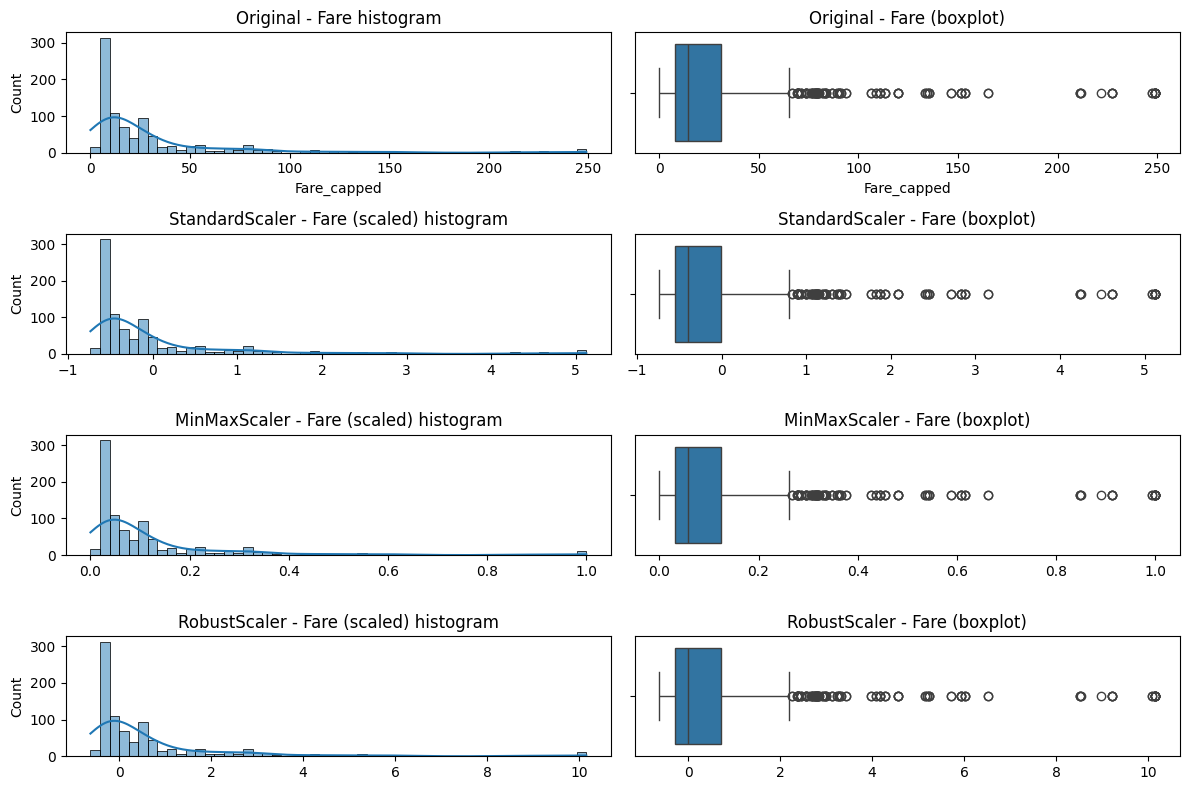

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
sample = sel_df[['Age_median','Fare_capped']].copy().dropna()

scalers = {
    'Original': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

plt.figure(figsize=(12,8))
for i,(name, sc) in enumerate(scalers.items(), 1):
    plt.subplot(4,2,2*(i-1)+1)
    if sc is None:
        sns.histplot(sample['Fare_capped'], kde=True)
        plt.title(name + ' - Fare histogram')
    else:
        transformed = sc.fit_transform(sample)
        sns.histplot(transformed[:,1], kde=True)
        plt.title(name + ' - Fare (scaled) histogram')
    plt.subplot(4,2,2*(i-1)+2)
    if sc is None:
        sns.boxplot(x=sample['Fare_capped'])
    else:
        sns.boxplot(x=transformed[:,1])
    plt.title(name + ' - Fare (boxplot)')
plt.tight_layout()
plt.show()

Original: Shows the raw/capped fare, revealing strong skew and many outliers.​

StandardScaler: Centers and scales fares so the distribution has zero mean and unit variance, but outliers persist.​

MinMaxScaler: Scales all fares to the range, preserving skew and outliers within this interval.​

RobustScaler: Scales using median and interquartile range, less sensitive to extreme outliers but still shows outliers.

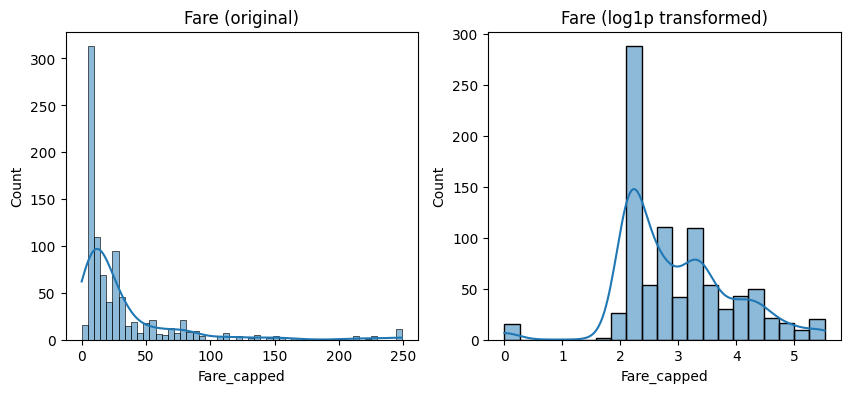

In [ ]:
# Log transform demonstration for skewed Fare
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(sample['Fare_capped'], kde=True)
plt.title('Fare (original)')

plt.subplot(1,2,2)
sns.histplot(np.log1p(sample['Fare_capped']), kde=True)
plt.title('Fare (log1p transformed)')
plt.show()

####What it does?

The left plot shows the original fares (how much people paid for their tickets) using a histogram.

The right plot shows what those fares look like after applying a mathematical transformation, where every fare is replaced with its logarithm (using np.log1p, which means log(fare + 1)).

The transformation makes the distribution look much more "spread out" and less lopsided. In the original data, most fares are small and a few are extremely large, so the histogram is pushed to one side. The log transformation helps squash the effect of large outlier fares and bring the data closer to a normal (bell-shaped) distribution, making it easier for models to handle.

## 7) Preprocessing Pipelines (ColumnTransformer + Pipeline)

**Teaching note:** Pipelines prevent leakage by fitting transformations only on training data. Use ColumnTransformer to apply different transforms to numeric vs categorical columns.


### Why Use Pipelines and ColumnTransformer in Preprocessing?

In machine learning, a key step is **preprocessing**: cleaning and transforming data so models can learn effectively. Two common problems students face are:

- Accidentally using information from the test set when fitting transformers (called **data leakage**)
- Applying the same transformation to all columns when different types—like numbers and categories—need different treatment

**Pipelines** solve the leakage problem by ensuring each step (like imputing missing values or scaling) is fitted only on the training data, never the test data. This means when you split your dataset (like Titanic) into training and testing, everything you do to train is "blind" to the test set, so your accuracy results are realistic and honest.

**ColumnTransformer** allows you to specify different preprocessing for different columns:

- Here, `numeric_transformer` imputes missing numbers with their median (good for skewed data), then uses `RobustScaler` to shrink the effect of outliers.
- The `preprocessor` applies this numeric pipeline to all numeric columns while leaving other columns unchanged (`remainder='passthrough'`).

By wrapping all steps—including a model (RandomForestClassifier)—in a single `Pipeline`, you can split your data, train, and test all in one line, confident there’s no cheating. This keeps your workflow organized, prevents errors, and makes your code reusable and easy to understand.

**In summary:**

- ColumnTransformer enables different transformations for each data type.
- Pipeline chains preprocessing and modeling, making sure evaluation is fair.
- This approach works for any dataset, not just Titanic, and is a best practice for reliable machine learning.

In [ ]:
from sklearn.impute import SimpleImputer
# Example pipeline: impute numeric features, scale, then train a simple model in the same pipeline
numeric_cols = ['Age_median','Fare_capped','SibSp','Parch']
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_cols)], remainder='passthrough')
#using RandomForestClassifier Model
model_pipeline = Pipeline([('preprocessor', preprocessor), ('clf', RandomForestClassifier(n_estimators=50, random_state=42))])

# Train/test split demonstration
from sklearn.model_selection import train_test_split
X_full = sel_df.drop(['Survived', 'Embarked_mode'], axis=1) # Drop Embarked_mode column
y_full = sel_df['Survived']
#using a 80-20 Split
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
model_pipeline.fit(X_tr, y_tr)
print('Pipeline test accuracy:', model_pipeline.score(X_te, y_te))

Pipeline test accuracy: 0.7988826815642458


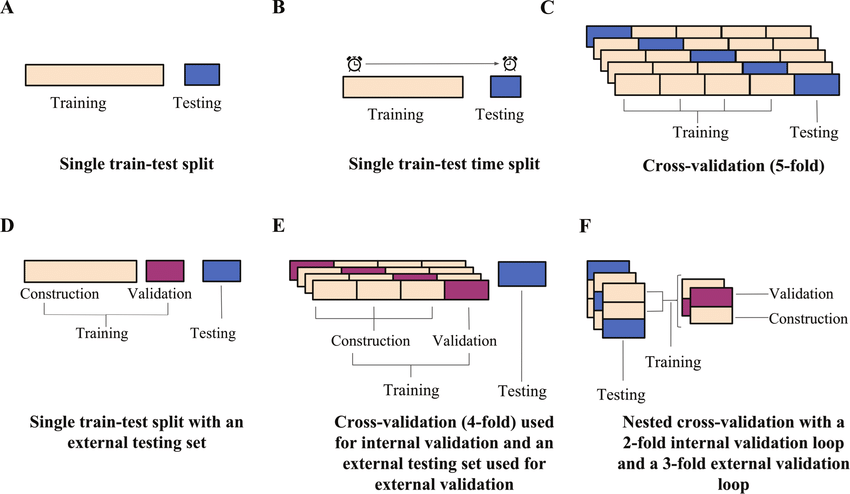

This diagram explains different ways to split up a dataset in machine learning to train, tune, and test your models. The goal is to check how well your model works without accidentally "cheating" by testing on data it already saw during training.

### Explanation of Each Method

- **A. Single train-test split:**
You divide your data into two parts: one for training the model, one for testing (checking) how well it works. This is very simple but might not give reliable performance results every time.
- **B. Single train-test time split:**
Similar to A, but the split is done according to time. For example, you train on older data and test on newer data. This is useful when the order or timing matters (like predicting future events).
- **C. Cross-validation (5-fold):**
You divide your data into 5 parts ("folds"). You train on 4 parts and test on the remaining part, repeating this so every piece gets tested. This gives a better idea of how well the model works overall, using every part for testing at least once.
- **D. Single train-test split with an external testing set:**
You use most data for training and validation (tuning), but keep a totally separate set for final testing. This makes sure the last test is on data the model never saw, for a true performance check.
- **E. Cross-validation (4-fold) with an external testing set:**
You do cross-validation within your training data for tuning, then test the final model on an external set, giving you reliable results with both internal checks and a final external score.
- **F. Nested cross-validation:**
This combines both inner and outer validation loops (think of repeating splits inside splits). It's used when you want to pick the best model or settings while making absolutely sure your final test is completely independent.


### Why We Do This

- **Prevent cheating:** We want to know if the model will work on new, unseen data—not just the data it already saw.
- **Tune and select models:** Validation splits (or loops) let us try different approaches/settings and pick the best one, but we don’t use the test set for this, to keep things fair.
- **Get reliable results:** Advanced schemes like cross-validation and nested validation help us make sure our model's results are trustworthy and not random.

Splitting and resampling methods like these are key for building machine learning models that work well in real-life situations, not just on the data we already have. We will see more in the next notebook


## 8) Exercises & Teaching Notes

- Replace the dataset with your own CSV and follow the cleaning steps.
- Try different imputation strategies for Age (mean vs median vs KNN) and compare model accuracy.
- Explore target encoding for a high-cardinality categorical column (not in Titanic) and discuss leakage risks.

**End of preprocessing notebook.**